In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as _sum, avg, round as _round,
    desc, when, lit, month, log1p
)
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
import time, warnings
warnings.filterwarnings("ignore")

spark = SparkSession.builder \
    .appName("Brand_Clustering") \
    .config("spark.driver.memory", "3g") \
    .config("spark.sql.shuffle.partitions", "2") \
    .config("spark.default.parallelism", "2") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(f"Spark: {spark.version}")

Spark: 3.4.0


In [2]:
# Dùng clean_data (toàn bộ 2.2M dòng, kể cả khách vãng lai)
# vì phân tích brand không cần biết ai mua
df = spark.read.parquet("/home/jovyan/work/data/clean_data/")

print(f"Tổng dòng     : {df.count():,}")
print(f"Cột           : {df.columns}")
df.show(3, truncate=False)

Tổng dòng     : 2,185,221
Cột           : ['event_time', 'order_id', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'date', 'category_lv1', 'category_lv2', 'year', 'month']
+-------------------+-------------------+-------------------+-------------------+---------------------------+-------+-----+-------------------+----------+------------+------------+----+-----+
|event_time         |order_id           |product_id         |category_id        |category_code              |brand  |price|user_id            |date      |category_lv1|category_lv2|year|month|
+-------------------+-------------------+-------------------+-------------------+---------------------------+-------+-----+-------------------+----------+------------+------------+----+-----+
|2020-06-01 03:54:54|2321661959021265496|2273948310182035866|2268105430162997728|electronics.audio.headphone|unknown|37.01|1515915625441042396|2020-06-01|electronics |audio       |2020|6    |
|2020-06-01 03:58:55|2321663977

In [3]:
# Aggregate toàn bộ theo brand
brand_stats = df \
    .filter(col("brand") != "unknown") \
    .groupBy("brand") \
    .agg(
        _round(_sum("price"),  2).alias("total_revenue"),
        count("*").alias("so_don"),
        _round(avg("price"),   2).alias("avg_price"),
        count(col("user_id").isNotNull().cast("int")).alias("so_khach")
    ) \
    .filter(col("so_don") >= 50)  # loại brand có quá ít đơn

total_brand = brand_stats.count()
print(f"Số brand đủ điều kiện: {total_brand:,}")
print("\n=== Top 15 brand theo doanh thu ===")
brand_stats.orderBy(desc("total_revenue")).show(15)

Số brand đủ điều kiện: 399

=== Top 15 brand theo doanh thu ===
+----------+-------------+------+---------+--------+
|     brand|total_revenue|so_don|avg_price|so_khach|
+----------+-------------+------+---------+--------+
|   samsung|8.953012201E7|356343|   251.25|  356343|
|     apple|4.750835508E7| 74026|   641.78|   74026|
|        lg| 2.59881632E7| 55321|   469.77|   55321|
|     bosch|1.102492188E7| 33728|   326.88|   33728|
|    huawei|1.064268051E7| 56648|   187.87|   56648|
|      asus|1.060618669E7| 20524|   516.77|   20524|
|    lenovo|1.049365979E7| 19586|   535.77|   19586|
|       ava|   8495886.71|117447|    72.34|  117447|
|      beko|   8441977.75| 32003|   263.79|   32003|
|      oppo|   7257887.72| 36073|    201.2|   36073|
|     tefal|    6409954.9| 78136|    82.04|   78136|
|        hp|   6002012.38| 19792|   303.25|   19792|
|      sony|   5808053.95| 26617|   218.21|   26617|
|electrolux|   4986130.35| 12729|   391.71|   12729|
|    xiaomi|   4426721.77| 33015|  

In [4]:
# Tính doanh thu từng brand theo tháng
brand_monthly = df \
    .filter(col("brand") != "unknown") \
    .groupBy("brand", "month") \
    .agg(_round(_sum("price"), 2).alias("revenue")) \
    .orderBy("brand", "month")

# Tính trend: so sánh doanh thu nửa sau (tháng 8-11)
# với nửa đầu (tháng 4-7)
first_half  = brand_monthly.filter(col("month") <= 7) \
    .groupBy("brand") \
    .agg(_round(avg("revenue"), 2).alias("rev_first_half"))

second_half = brand_monthly.filter(col("month") >= 8) \
    .groupBy("brand") \
    .agg(_round(avg("revenue"), 2).alias("rev_second_half"))

# Gộp lại tính trend score
brand_trend = first_half.join(second_half, on="brand", how="inner") \
    .withColumn("trend_score",
        _round((col("rev_second_half") - col("rev_first_half"))
               / (col("rev_first_half") + lit(1)) * 100, 2))

print("=== Xu hướng tăng/giảm theo brand (Top 10 tăng) ===")
brand_trend.orderBy(desc("trend_score")).show(10)

print("=== Top 10 giảm mạnh nhất ===")
brand_trend.orderBy("trend_score").show(10)

=== Xu hướng tăng/giảm theo brand (Top 10 tăng) ===
+-----------+--------------+---------------+-----------+
|      brand|rev_first_half|rev_second_half|trend_score|
+-----------+--------------+---------------+-----------+
|      stels|          3.22|        1593.83|   37692.18|
|      artel|        300.88|       10913.81|    3515.61|
|    allvega|          3.39|         155.51|    3465.15|
|bridgestone|        122.43|        2668.56|    2062.81|
|      kiepe|          3.28|          81.94|    1837.85|
|    energea|        116.38|        2056.35|    1652.73|
|    rossija|           5.0|         104.05|    1650.83|
|       dell|       3282.54|       56327.33|    1615.48|
|     wintek|         78.18|        1132.93|    1332.09|
|   michelin|        232.33|        3153.39|     1251.9|
+-----------+--------------+---------------+-----------+
only showing top 10 rows

=== Top 10 giảm mạnh nhất ===
+--------+--------------+---------------+-----------+
|   brand|rev_first_half|rev_second_half

In [5]:
# Join brand_stats với brand_trend
brand_features = brand_stats.join(brand_trend, on="brand", how="left") \
    .fillna({"trend_score": 0,
             "rev_first_half": 0,
             "rev_second_half": 0})

# Log transform vì revenue phân phối lệch phải
brand_features = brand_features \
    .withColumn("revenue_log",  log1p(col("total_revenue"))) \
    .withColumn("don_log",      log1p(col("so_don")))

print(f"Brand đưa vào clustering: {brand_features.count():,}")
brand_features.select(
    "brand", "total_revenue", "so_don",
    "avg_price", "trend_score",
    "revenue_log", "don_log"
).show(10)

# Cache
brand_features.cache()
brand_features.count()
print("Cache xong!")

Brand đưa vào clustering: 399
+--------+-------------+------+---------+-----------+------------------+------------------+
|   brand|total_revenue|so_don|avg_price|trend_score|       revenue_log|           don_log|
+--------+-------------+------+---------+-----------+------------------+------------------+
|aerocool|    119448.61|  1011|   118.15|     130.91|11.690649887784206| 6.919683849847411|
| akvafor|    218215.59| 23992|      9.1|     -24.23|12.293243380654955|10.085517400120422|
|     ava|   8495886.71|117447|    72.34|     -31.64|15.955092805568604|11.673750961419296|
|    beko|   8441977.75| 32003|   263.79|     -57.34|15.948727288145388|10.373616173970015|
|   bosch|1.102492188E7| 33728|   326.88|      12.97| 16.21566898426138| 10.42611328041787|
|delonghi|   1642802.13|  6774|   242.52|      11.47|14.311914566346388| 8.820994645747902|
|   eyfel|       378.03|    51|     7.41|      49.94|5.9376153576226045|3.9512437185814275|
|     ggg|    117202.22|  5667|    20.68|     -35.

In [6]:
assembler = VectorAssembler(
    inputCols=["revenue_log", "don_log", "avg_price", "trend_score"],
    outputCol="features_raw"
)
scaler = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withStd=True, withMean=True
)
kmeans = KMeans(featuresCol="features", k=4, seed=42, maxIter=20)

pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model    = pipeline.fit(brand_features)
brand_pred = model.transform(brand_features)

print("=== Đặc trưng từng cluster brand ===")
brand_pred.groupBy("prediction").agg(
    _round(avg("total_revenue"), 0).alias("avg_revenue"),
    _round(avg("so_don"),        0).alias("avg_don"),
    _round(avg("avg_price"),     1).alias("avg_price"),
    _round(avg("trend_score"),   1).alias("avg_trend"),
    count("*").alias("so_brand")
).orderBy("prediction").show()

=== Đặc trưng từng cluster brand ===
+----------+-----------+-------+---------+---------+--------+
|prediction|avg_revenue|avg_don|avg_price|avg_trend|so_brand|
+----------+-----------+-------+---------+---------+--------+
|         0|  1474746.0|12057.0|     84.0|      6.7|     148|
|         1|  2782992.0| 5178.0|    516.1|    113.7|      39|
|         2|     6379.0|   70.0|     91.1|  37692.2|       1|
|         3|    13793.0|  386.0|     54.8|     70.3|     211|
+----------+-----------+-------+---------+---------+--------+



In [7]:

brand_labeled = brand_pred.withColumn("brand_segment",
    when(col("prediction") == 0, "Hot")        # Revenue cao, đơn nhiều, trend dương
    .when(col("prediction") == 1, "Premium")   # Revenue rất cao, giá cao, ít đơn
    .when(col("prediction") == 2, "Rising")    # Trend đột biến, brand mới nổi (1 brand)
    .when(col("prediction") == 3, "Niche")     # Revenue thấp, đơn ít, giá rẻ
)

print("=== Phân bố brand segment ===")
brand_labeled.groupBy("brand_segment").agg(
    count("*").alias("so_brand"),
    _round(avg("total_revenue"), 0).alias("avg_revenue"),
    _round(avg("trend_score"),   1).alias("avg_trend")
).orderBy("so_brand").show()

print("\n=== Top 5 brand trong từng nhóm ===")
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

window = Window.partitionBy("brand_segment") \
               .orderBy(desc("total_revenue"))

brand_labeled \
    .withColumn("rank", rank().over(window)) \
    .filter(col("rank") <= 5) \
    .select("brand_segment", "brand", "total_revenue",
            "so_don", "avg_price", "trend_score") \
    .orderBy("brand_segment", "rank") \
    .show(20, truncate=False)

=== Phân bố brand segment ===
+-------------+--------+-----------+---------+
|brand_segment|so_brand|avg_revenue|avg_trend|
+-------------+--------+-----------+---------+
|       Rising|       1|     6379.0|  37692.2|
|      Premium|      39|  2782992.0|    113.7|
|          Hot|     148|  1474746.0|      6.7|
|        Niche|     211|    13793.0|     70.3|
+-------------+--------+-----------+---------+


=== Top 5 brand trong từng nhóm ===
+-------------+----------+-------------+------+---------+-----------+
|brand_segment|brand     |total_revenue|so_don|avg_price|trend_score|
+-------------+----------+-------------+------+---------+-----------+
|Hot          |samsung   |8.953012201E7|356343|251.25   |18.95      |
|Hot          |bosch     |1.102492188E7|33728 |326.88   |12.97      |
|Hot          |huawei    |1.064268051E7|56648 |187.87   |-46.11     |
|Hot          |ava       |8495886.71   |117447|72.34    |-31.64     |
|Hot          |beko      |8441977.75   |32003 |263.79   |-57.34   

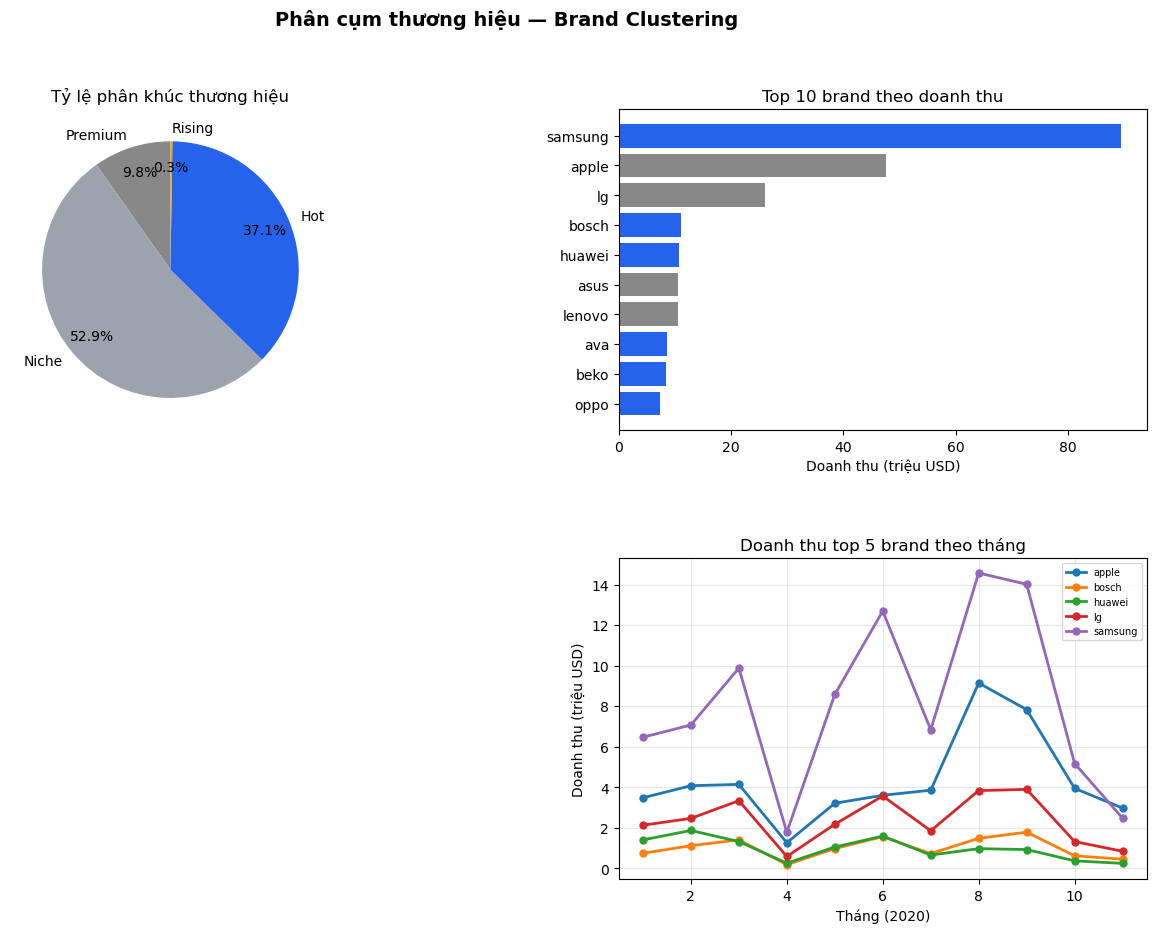

Lưu biểu đồ xong!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

COLORS = {
    "Hot"     : "#2563EB",
    "Stable"  : "#16A34A",
    "Rising": "#F59E0B",
    "Niche"   : "#9CA3AF"
}

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Phân cụm thương hiệu — Brand Clustering",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Pie chart phân bố brand segment ───────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
seg_pd = brand_labeled.groupBy("brand_segment").count().toPandas()
colors = [COLORS.get(s, "#888") for s in seg_pd["brand_segment"]]
ax1.pie(seg_pd["count"], labels=seg_pd["brand_segment"],
        autopct="%1.1f%%", colors=colors,
        startangle=90, pctdistance=0.8)
ax1.set_title("Tỷ lệ phân khúc thương hiệu")

# ── 2. Top 10 brand doanh thu ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top10 = brand_labeled \
    .orderBy(desc("total_revenue")).limit(10).toPandas()
bar_colors = [COLORS.get(s, "#888") for s in top10["brand_segment"]]
ax2.barh(top10["brand"][::-1],
         top10["total_revenue"][::-1] / 1e6,
         color=bar_colors[::-1])
ax2.set_title("Top 10 brand theo doanh thu")
ax2.set_xlabel("Doanh thu (triệu USD)")
# ── 3. Doanh thu top 5 brand theo tháng ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
top5_brands = brand_labeled \
    .orderBy(desc("total_revenue")) \
    .limit(5) \
    .select("brand") \
    .rdd.flatMap(lambda x: x).collect()

monthly_pd = df \
    .filter(col("brand").isin(top5_brands)) \
    .groupBy("brand", "month") \
    .agg(_round(_sum("price"), 0).alias("revenue")) \
    .orderBy("brand", "month") \
    .toPandas()

for brand_name, grp in monthly_pd.groupby("brand"):
    ax4.plot(grp["month"], grp["revenue"] / 1e6,
             "o-", label=brand_name, linewidth=2, markersize=5)
ax4.set_title("Doanh thu top 5 brand theo tháng")
ax4.set_xlabel("Tháng (2020)")
ax4.set_ylabel("Doanh thu (triệu USD)")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

plt.savefig("/home/jovyan/work/data/brand_clusters.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("Lưu biểu đồ xong!")

In [11]:
OUT_BRAND = "/home/jovyan/work/data/brand_result/"

brand_labeled.select(
    "brand", "total_revenue", "so_don",
    "avg_price", "trend_score", "brand_segment"
).write.mode("overwrite").parquet(OUT_BRAND)
print(f"Parquet lưu xong → {OUT_BRAND}")

# Ghi vào Cassandra
try:
    brand_labeled.select(
        col("brand"),
        col("total_revenue").cast("double"),
        col("so_don").cast("int"),
        col("avg_price").cast("double"),
        col("trend_score").cast("double"),
        col("brand_segment")
    ).write \
        .format("org.apache.spark.sql.cassandra") \
        .option("keyspace", "ecommerce") \
        .option("table",    "brand_segments") \
        .mode("append") \
        .save()
    print("Cassandra lưu xong!")
except Exception as e:
    print(f"Cassandra skip: {e}")

print("\nBrand Clustering hoàn tất!")

Parquet lưu xong → /home/jovyan/work/data/brand_result/
Cassandra skip: An error occurred while calling o693.save.
: org.apache.spark.SparkClassNotFoundException: [DATA_SOURCE_NOT_FOUND] Failed to find the data source: org.apache.spark.sql.cassandra. Please find packages at `https://spark.apache.org/third-party-projects.html`.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.dataSourceNotFoundError(QueryExecutionErrors.scala:738)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSource(DataSource.scala:647)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSourceV2(DataSource.scala:697)
	at org.apache.spark.sql.DataFrameWriter.lookupV2Provider(DataFrameWriter.scala:860)
	at org.apache.spark.sql.DataFrameWriter.saveInternal(DataFrameWriter.scala:256)
	at org.apache.spark.sql.DataFrameWriter.save(DataFrameWriter.scala:247)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.Native